In [107]:
import re
import pandas as pd

In [108]:
f=open('WhatsApp Chat with MCA 2025 Unofficial.txt','r',encoding='utf-8')

In [109]:
data=f.read()
print(data)

8/27/25, 5:48 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
8/16/25, 12:49 PM - ~ Rashaad🖤 created group "MCA 2025"
8/27/25, 5:48 PM - ~ Rashaad🖤 added you
8/28/25, 9:22 AM - ~ Rashaad🖤 added Zaid Ali and ~ Ubaid
8/28/25, 9:01 AM - +91 99976 14971: MCA Students ko kaha pochna hai induction ka liya?
8/28/25, 9:05 AM - Shayan JHU: Convention centre
8/28/25, 9:05 AM - +91 84454 89496: Convention hall 1
8/28/25, 9:14 AM - +91 98717 88240: Is it compulsory ?
8/28/25, 9:17 AM - +91 84454 89496: Yes
8/28/25, 10:50 AM - Rashid JH: Koi aya hai ajj
8/28/25, 10:51 AM - Rashid JH: College?
8/28/25, 10:52 AM - +91 98716 69676: sb hai
8/28/25, 10:53 AM - +91 98717 88240: Kl bhi induction program ha ?
8/28/25, 10:53 AM - +91 98717 88240: Aj last ha
8/28/25, 10:53 AM - +91 98716 69676: aaj hi h
8/28/25, 10:54 AM - +91 98717 88240: Ok
8/28/25, 11:08 AM - ~ Rashaad🖤 added ~ Umra
8/28/25, 11:29 AM - Shayan JHU: <Media omitted>
8

In [110]:
pattern = r'\d{1,2}\/\d{1,2}\/\d{2},\s\d{1,2}:\d{2}\s(?:AM|PM)'

In [111]:
messages=re.split(pattern,data)[1:]
print(messages)

[' - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.\n', ' - ~\u202fRashaad🖤 created group "MCA 2025"\n', ' - ~\u202fRashaad🖤 added you\n', ' - ~\u202fRashaad🖤 added Zaid Ali and ~\u202fUbaid\n', ' - +91 99976 14971: MCA Students ko kaha pochna hai induction ka liya?\n', ' - Shayan JHU: Convention centre\n', ' - +91 84454 89496: Convention hall 1\n', ' - +91 98717 88240: Is it compulsory ?\n', ' - +91 84454 89496: Yes\n', ' - Rashid JH: Koi aya hai ajj\n', ' - Rashid JH: College?\n', ' - +91 98716 69676: sb hai\n', ' - +91 98717 88240: Kl bhi induction program ha ?\n', ' - +91 98717 88240: Aj last ha\n', ' - +91 98716 69676: aaj hi h\n', ' - +91 98717 88240: Ok\n', ' - ~\u202fRashaad🖤 added ~\u202fUmra\n', ' - Shayan JHU: <Media omitted>\n', ' - +91 81264 40047: Sab gye hai kya\n', ' - Zidaan: Kab tak chalega koi idea ?\n', ' - Md Shayan JHU: Nh\n', ' - Rashid JH: Jaa rha hu\n', ' - Md Shayan JHU: Shaam Tk\n', ' - +9

In [112]:
dates=re.findall(pattern,data)
dates

['8/27/25, 5:48\u202fPM',
 '8/16/25, 12:49\u202fPM',
 '8/27/25, 5:48\u202fPM',
 '8/28/25, 9:22\u202fAM',
 '8/28/25, 9:01\u202fAM',
 '8/28/25, 9:05\u202fAM',
 '8/28/25, 9:05\u202fAM',
 '8/28/25, 9:14\u202fAM',
 '8/28/25, 9:17\u202fAM',
 '8/28/25, 10:50\u202fAM',
 '8/28/25, 10:51\u202fAM',
 '8/28/25, 10:52\u202fAM',
 '8/28/25, 10:53\u202fAM',
 '8/28/25, 10:53\u202fAM',
 '8/28/25, 10:53\u202fAM',
 '8/28/25, 10:54\u202fAM',
 '8/28/25, 11:08\u202fAM',
 '8/28/25, 11:29\u202fAM',
 '8/28/25, 11:35\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:36\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:37\u202fAM',
 '8/28/25, 11:38\u202fAM',
 '8/28/25, 11:38\u202fAM',
 '8/28/25, 11:38\u202fAM',
 '8/28/25, 11:38\u202fAM',
 '8/28/25

In [113]:
df = pd.DataFrame({'user_message': messages, "message_date": dates})
df['message_date'] = df['message_date'].str.replace('\u202f', ' ', regex=True)
df['message_date'] = pd.to_datetime(df['message_date'], format='%m/%d/%y, %I:%M %p')
df.rename(columns={'message_date': 'date'}, inplace=True)
df['user_message'] = df['user_message'].fillna('').astype(str).str.lstrip('- ').str.strip()
df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. O...,2025-08-27 17:48:00
1,"~ Rashaad🖤 created group ""MCA 2025""",2025-08-16 12:49:00
2,~ Rashaad🖤 added you,2025-08-27 17:48:00
3,~ Rashaad🖤 added Zaid Ali and ~ Ubaid,2025-08-28 09:22:00
4,+91 99976 14971: MCA Students ko kaha pochna h...,2025-08-28 09:01:00


In [114]:
users=[]
messages=[]
for message in df['user_message']:
    entry=re.split(r'^([\w\s\+\-\(\)]+?):\s(.*)',message)
    if entry[1:]:
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])
df['user']=users
df['messages']=messages
df.drop(columns=['user_message'],inplace=True)
df.head()

,date,user,messages
0,2025-08-27 17:48:00,group_notification,Messages and calls are end-to-end encrypted. O...
1,2025-08-16 12:49:00,group_notification,"~ Rashaad🖤 created group ""MCA 2025"""
2,2025-08-27 17:48:00,group_notification,~ Rashaad🖤 added you
3,2025-08-28 09:22:00,group_notification,~ Rashaad🖤 added Zaid Ali and ~ Ubaid
4,2025-08-28 09:01:00,+91 99976 14971,MCA Students ko kaha pochna hai induction ka l...


In [115]:
df['year']=df['date'].dt.year

In [116]:
df.head()

,date,user,messages,year
0,2025-08-27 17:48:00,group_notification,Messages and calls are end-to-end encrypted. O...,2025
1,2025-08-16 12:49:00,group_notification,"~ Rashaad🖤 created group ""MCA 2025""",2025
2,2025-08-27 17:48:00,group_notification,~ Rashaad🖤 added you,2025
3,2025-08-28 09:22:00,group_notification,~ Rashaad🖤 added Zaid Ali and ~ Ubaid,2025
4,2025-08-28 09:01:00,+91 99976 14971,MCA Students ko kaha pochna hai induction ka l...,2025


In [117]:
df['month']= df['date'].dt.month_name()

In [118]:
df['day']= df['date'].dt.day

In [119]:
df['hour']=df['date'].dt.hour

In [120]:
df['minute']=df['date'].dt.minute

In [121]:
df.head()

,date,user,messages,year,month,day,hour,minute
0,2025-08-27 17:48:00,group_notification,Messages and calls are end-to-end encrypted. O...,2025,August,27,17,48
1,2025-08-16 12:49:00,group_notification,"~ Rashaad🖤 created group ""MCA 2025""",2025,August,16,12,49
2,2025-08-27 17:48:00,group_notification,~ Rashaad🖤 added you,2025,August,27,17,48
3,2025-08-28 09:22:00,group_notification,~ Rashaad🖤 added Zaid Ali and ~ Ubaid,2025,August,28,9,22
4,2025-08-28 09:01:00,+91 99976 14971,MCA Students ko kaha pochna hai induction ka l...,2025,August,28,9,1


In [122]:
from urlextract import URLExtract
extractor=URLExtract()
urls=extractor.find_urls('https://www.google.com','https://www.youtube.com','https://www.instagram.com','https://www.gmail.com','https://www.facebook.com')
urls

[('https://www.google.com', (0, 22))]

In [123]:
links=[]
for message in df['messages']:
    links.extend(extractor.find_urls(message))

In [124]:
len(links)

37

In [125]:
x=df['user'].value_counts().head()

In [126]:
import matplotlib.pyplot as plt

In [127]:
name= x.index
count= x.values

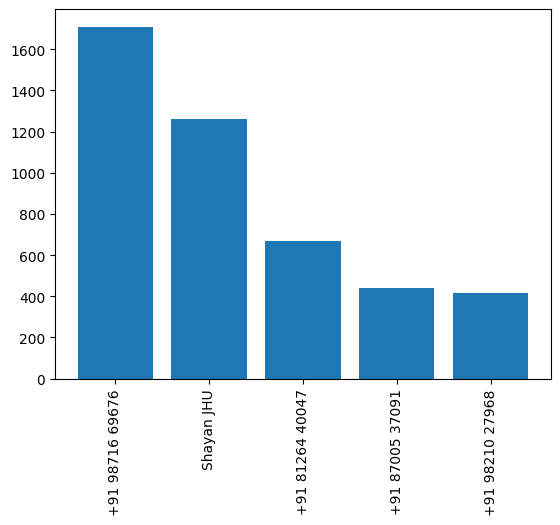

In [128]:
plt.bar(name,count)
plt.xticks(rotation="vertical")
plt.show()

In [129]:
df_user_percent = (
    df['user'].value_counts(normalize=True) * 100
).round(2).reset_index().rename(
    columns={'percent': 'name', 'count': 'percent'}
)


In [130]:
temp=df[df['user'] != 'group_notification']
temp=temp[temp['messages'] != '<Media ommited>\n']

In [131]:
f=open('stop_hinglish.txt','r')
stop_words=f.read()

In [132]:
words=[]
for message in temp['messages']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [133]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,<media,848
1,omitted>,848
2,message,494
3,deleted,368
4,class,298
5,hn,178
6,😂😂,151
7,mam,148
8,lab,117
9,sb,114


In [134]:
import emoji

In [135]:
import emoji

emojis = []
for message in df['messages']:
    emojis.extend([c for c in message if emoji.is_emoji(c)])

In [136]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

,0,1
0,😂,972
1,🤣,265
2,💀,150
3,🖤,88
4,🥲,80
...,...,...
109,📏,1
110,🤲,1
111,📢,1
112,😉,1


In [137]:
df['month_num']=df['date'].dt.month

In [138]:
df

,date,user,messages,year,month,day,hour,minute,month_num
0,2025-08-27 17:48:00,group_notification,Messages and calls are end-to-end encrypted. O...,2025,August,27,17,48,8
1,2025-08-16 12:49:00,group_notification,"~ Rashaad🖤 created group ""MCA 2025""",2025,August,16,12,49,8
2,2025-08-27 17:48:00,group_notification,~ Rashaad🖤 added you,2025,August,27,17,48,8
3,2025-08-28 09:22:00,group_notification,~ Rashaad🖤 added Zaid Ali and ~ Ubaid,2025,August,28,9,22,8
4,2025-08-28 09:01:00,+91 99976 14971,MCA Students ko kaha pochna hai induction ka l...,2025,August,28,9,1,8
...,...,...,...,...,...,...,...,...,...
8584,2026-01-11 20:49:00,+91 98716 69676,are so jao kya krogi jakr,2026,January,11,20,49,1
8585,2026-01-11 20:51:00,+91 83689 05946,Nhi jaa rhi pr class bhi cancel ho😂,2026,January,11,20,51,1
8586,2026-01-11 20:51:00,+91 98716 69676,are yr,2026,January,11,20,51,1
8587,2026-01-11 20:52:00,+91 83689 05946,😂😂,2026,January,11,20,52,1


In [139]:
timeline=df.groupby(['year','month_num','month']).count()['messages'].reset_index()

In [140]:
timeline

,year,month_num,month,messages
0,2025,8,August,412
1,2025,9,September,3014
2,2025,10,October,785
3,2025,11,November,2788
4,2025,12,December,1438
5,2026,1,January,152


In [141]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i]+ "-" + str(timeline['year'][i]))

In [142]:
time

['August-2025',
 'September-2025',
 'October-2025',
 'November-2025',
 'December-2025',
 'January-2026']

In [143]:
timeline['time']=time

In [144]:
timeline

,year,month_num,month,messages,time
0,2025,8,August,412,August-2025
1,2025,9,September,3014,September-2025
2,2025,10,October,785,October-2025
3,2025,11,November,2788,November-2025
4,2025,12,December,1438,December-2025
5,2026,1,January,152,January-2026


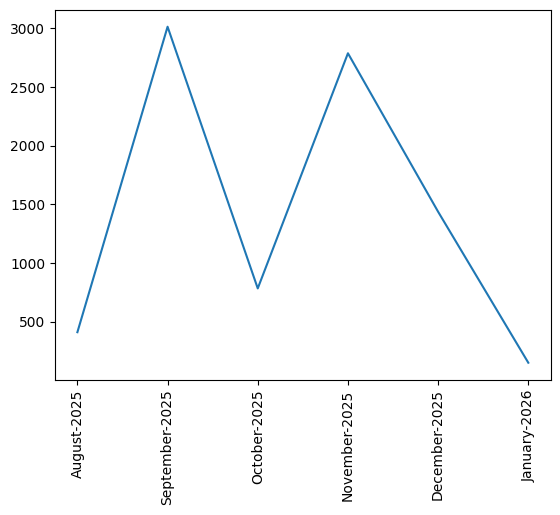

In [145]:
plt.plot(timeline['time'],timeline['messages'])
plt.xticks(rotation='vertical')
plt.show()

In [146]:
df['only_date']=df['date'].dt.date

In [147]:
daily_timeline=df.groupby('only_date').count()['messages'].reset_index()

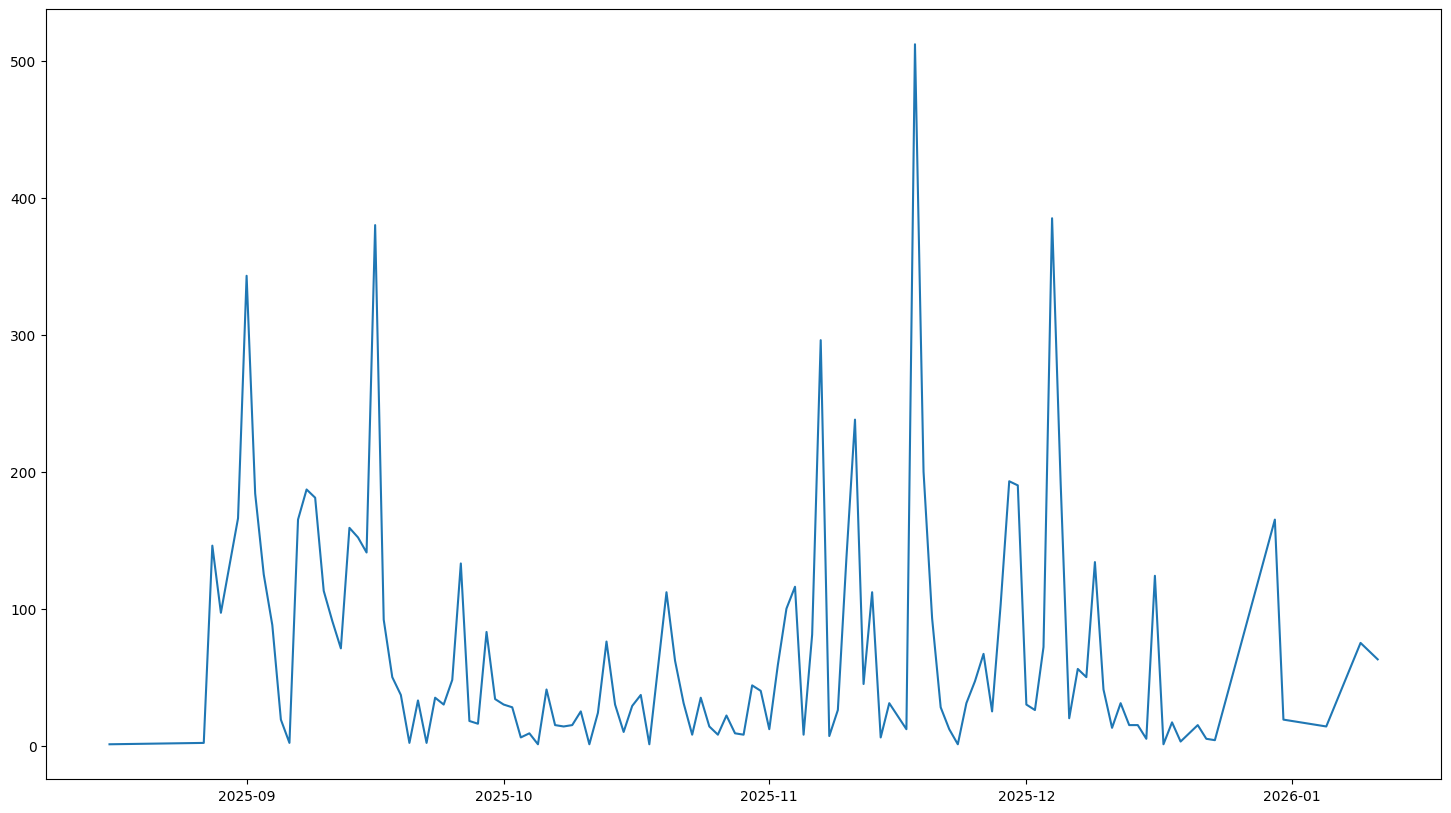

In [148]:
plt.figure(figsize=(18,10))
plt.plot(daily_timeline['only_date'],daily_timeline['messages'])

In [149]:
df['day_name']=df['date'].dt.day_name()

In [150]:
df['day_name'].value_counts()

day_name
Tuesday      2296
Monday       1391
Thursday     1273
Friday       1234
Sunday        990
Wednesday     908
Saturday      497
Name: count, dtype: int64

In [151]:
period=[]
for hour in df[['day_name','hour',]]['hour']:
    if hour==23:
        period.append(str(hour) + "=" + str('00'))
    elif hour==0:
        period.append(str('00')+ "-" + str(hour+1))
    else:
        period.append(str(hour) + "-" + str(hour+1))

In [152]:
df['period']=period

In [153]:
df.sample(5)
df

,date,user,messages,year,month,day,hour,minute,month_num,only_date,day_name,period
0,2025-08-27 17:48:00,group_notification,Messages and calls are end-to-end encrypted. O...,2025,August,27,17,48,8,2025-08-27,Wednesday,17-18
1,2025-08-16 12:49:00,group_notification,"~ Rashaad🖤 created group ""MCA 2025""",2025,August,16,12,49,8,2025-08-16,Saturday,12-13
2,2025-08-27 17:48:00,group_notification,~ Rashaad🖤 added you,2025,August,27,17,48,8,2025-08-27,Wednesday,17-18
3,2025-08-28 09:22:00,group_notification,~ Rashaad🖤 added Zaid Ali and ~ Ubaid,2025,August,28,9,22,8,2025-08-28,Thursday,9-10
4,2025-08-28 09:01:00,+91 99976 14971,MCA Students ko kaha pochna hai induction ka l...,2025,August,28,9,1,8,2025-08-28,Thursday,9-10
...,...,...,...,...,...,...,...,...,...,...,...,...
8584,2026-01-11 20:49:00,+91 98716 69676,are so jao kya krogi jakr,2026,January,11,20,49,1,2026-01-11,Sunday,20-21
8585,2026-01-11 20:51:00,+91 83689 05946,Nhi jaa rhi pr class bhi cancel ho😂,2026,January,11,20,51,1,2026-01-11,Sunday,20-21
8586,2026-01-11 20:51:00,+91 98716 69676,are yr,2026,January,11,20,51,1,2026-01-11,Sunday,20-21
8587,2026-01-11 20:52:00,+91 83689 05946,😂😂,2026,January,11,20,52,1,2026-01-11,Sunday,20-21


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, 'Friday'),
  Text(0, 1.5, 'Monday'),
  Text(0, 2.5, 'Saturday'),
  Text(0, 3.5, 'Sunday'),
  Text(0, 4.5, 'Thursday'),
  Text(0, 5.5, 'Tuesday'),
  Text(0, 6.5, 'Wednesday')])

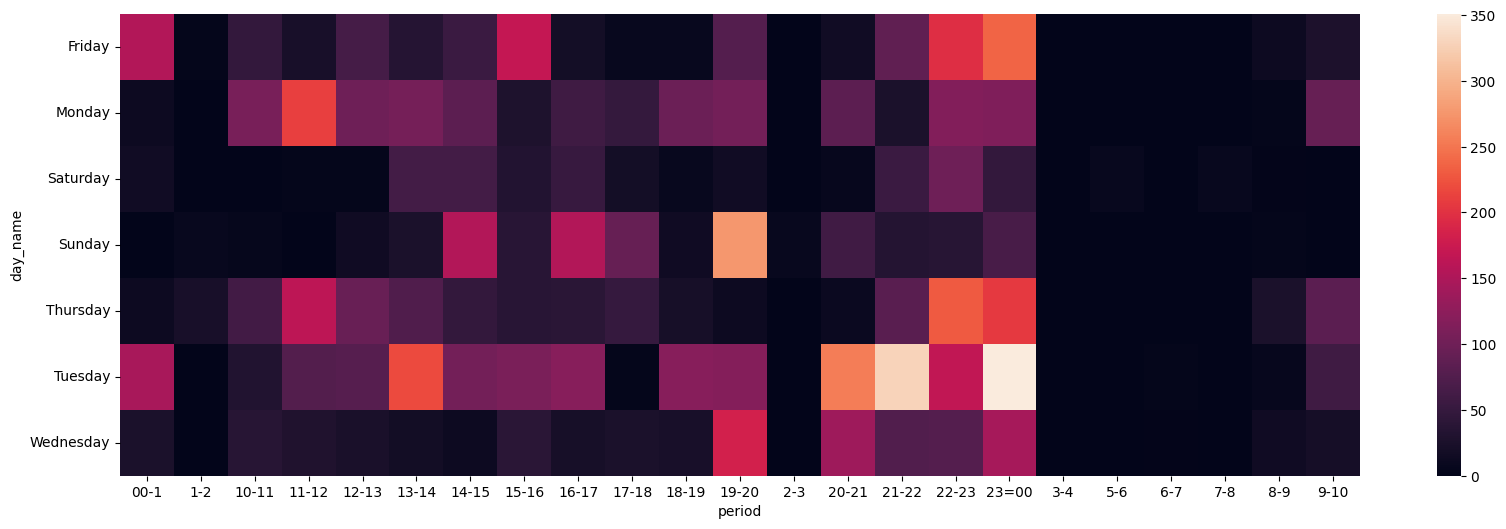

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,6))
sns.heatmap(df.pivot_table(index='day_name',columns='period',values='messages',aggfunc='count').fillna(0))
plt.yticks(rotation='horizontal')